In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [48]:
dataset = pd.read_csv("students.csv")

In [49]:
df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [50]:
df.isnull().sum()

,0
gradyear,0
gender,1337
age,2496
NumberOffriends,0
basketball,0
football,0
soccer,0
softball,0
volleyball,0
swimming,0


In [51]:
df.shape

(15000, 40)

In [52]:
# Convert gender to numbers
dataset["gender"] = dataset["gender"].fillna("Unknown")

encoder = LabelEncoder()

dataset["gender"] = encoder.fit_transform(dataset["gender"])

# Convert age to numeric
dataset["age"] = pd.to_numeric(dataset["age"], errors="coerce")

# Fill missing values
dataset = dataset.fillna(dataset.median(numeric_only=True))

print(dataset.isnull().sum())

gradyear           0
gender             0
age                0
NumberOffriends    0
basketball         0
football           0
soccer             0
softball           0
volleyball         0
swimming           0
cheerleading       0
baseball           0
tennis             0
sports             0
cute               0
Gender             0
Type               0
hot                0
kissed             0
dance              0
band               0
marching           0
music              0
rock               0
god                0
church             0
jesus              0
bible              0
hair               0
dress              0
blonde             0
mall               0
shopping           0
clothes            0
hollister          0
abercrombie        0
die                0
death              0
drunk              0
drugs              0
dtype: int64


In [53]:
X = dataset.copy()

In [54]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [55]:
dbscan = DBSCAN(
    eps=2.0,
    min_samples=8
)

clusters = dbscan.fit_predict(X_scaled)

dataset["Cluster"] = clusters

In [56]:
print(dataset["Cluster"].value_counts())

Cluster
-1     8593
 0     5374
 6      210
 7      175
 1      172
 4      131
 5       84
 2       82
 9       47
 12      29
 13      19
 3       18
 11      13
 16      11
 14      10
 15      10
 10       8
 17       8
 8        6
Name: count, dtype: int64


In [57]:
valid = dataset["Cluster"] != -1

if len(set(dataset.loc[valid, "Cluster"])) > 1:
    score = silhouette_score(
        X_scaled[valid],
        dataset.loc[valid, "Cluster"]
    )
    print("Silhouette Score =", round(score,4))
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score = 0.1153


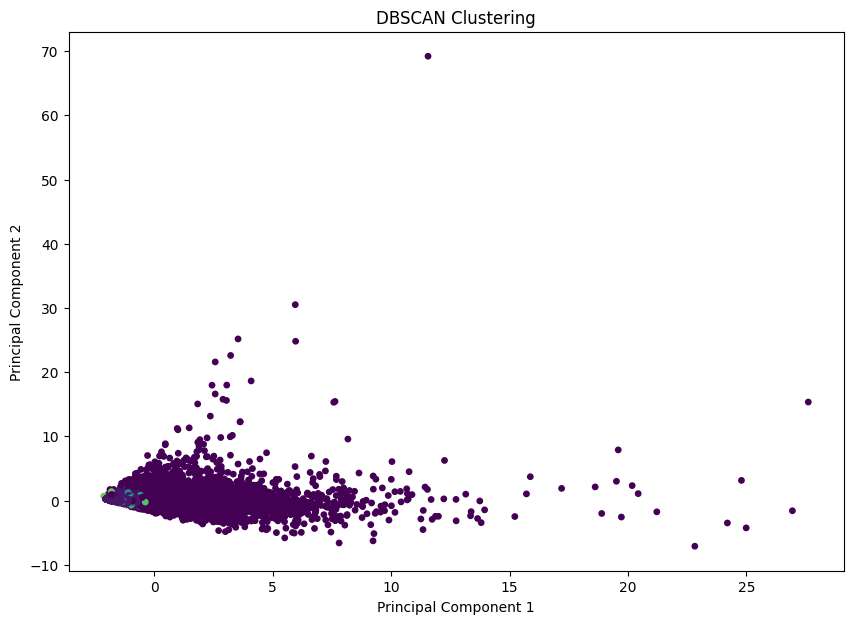

In [58]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dataset["Cluster"],
    s=15
)

plt.title("DBSCAN Clustering")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [59]:
dataset.to_csv(
    "students_DBSCAN.csv",
    index=False
)

print("students_DBSCAN.csv saved successfully.")

students_DBSCAN.csv saved successfully.


In [60]:
print(dataset["Cluster"].value_counts())

Cluster
-1     8593
 0     5374
 6      210
 7      175
 1      172
 4      131
 5       84
 2       82
 9       47
 12      29
 13      19
 3       18
 11      13
 16      11
 14      10
 15      10
 10       8
 17       8
 8        6
Name: count, dtype: int64


In [61]:
print(score)

0.11532480327610113


In [62]:
DBSCAN(eps=1.2, min_samples=8)

DBSCAN(eps=1.2, min_samples=8)

In [63]:
eps = 2.0
min_samples = 8

In [64]:
print(score)

0.11532480327610113
